## Tarea 3: Sistema Multiagente para Evaluación de Riesgo Crediticio

## Objetivo
Construir y analizar un **Sistema Multiagente (SMA)** para estimar el riesgo crediticio, utilizando datos reales del **German Credit Dataset** (UCI ML Repository).

Cada agente encapsula uno de los sistemas de inferencia difusa implementados en la Tarea 2 (Mamdani, Tsukamoto, TSK-1). Un **agente coordinador** integra sus propuestas para producir una solución global. 

## 1. Configuración inicial

In [1]:
# CONFIGURACIÓN INICIAL
# =====================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import threading
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Configuración estética
plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

np.random.seed(42)

print("Librerías cargadas exitosamente.\n")
print("=" * 70)
print("TAREA 3: SMA PARA EVALUACIÓN DE RIESGO CREDITICIO")
print("=" * 70)



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\Lenovo\AppData\Roaming\Python\Python312\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\Lenovo\AppData\Roaming\Python\Python312\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\Lenovo\AppData\Roaming\Python\Python312\site-packages\ipykernel\kernelapp.py", line 739, in start
    self.io

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "C:\Users\Lenovo\AppData\Roaming\Python\Python312\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\Lenovo\AppData\Roaming\Python\Python312\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "C:\Users\Lenovo\AppData\Roaming\Python\Python312\site-packages\ipykernel\kernelapp.py", line 739, in start
    self.io

ImportError: 
A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.3 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.



Librerías cargadas exitosamente.

TAREA 3: SMA PARA EVALUACIÓN DE RIESGO CREDITICIO


## 2. Carga y Preprocesamiento del Dataset

Reutilizamos el mismo flujo de la Tarea 2. El dataset se carga desde `ucimlrepo`; los
`Attribute` se renombran a nombres semánticos, y se extraen las cuatro variables de
entrada que alimentarán los sistemas difusos de cada agente.

In [22]:
# [2.1] Cargar German Credit Dataset vía ucimlrepo
from ucimlrepo import fetch_ucirepo

statlog = fetch_ucirepo(id=144)
X_raw = statlog.data.features
y_raw = statlog.data.targets

# Renombrado de columnas
rename_map = {
    'Attribute1':  'checking_account', 'Attribute2':  'duration',
    'Attribute3':  'credit_history',   'Attribute4':  'purpose',
    'Attribute5':  'amount',           'Attribute6':  'savings',
    'Attribute7':  'employment',       'Attribute8':  'installment_rate',
    'Attribute9':  'personal_status',  'Attribute10': 'other_debtors',
    'Attribute11': 'residence_since',  'Attribute12': 'property',
    'Attribute13': 'age',              'Attribute14': 'other_installments',
    'Attribute15': 'housing',          'Attribute16': 'existing_credits',
    'Attribute17': 'job',              'Attribute18': 'dependents',
    'Attribute19': 'telephone',        'Attribute20': 'foreign_worker',
}

df_raw = X_raw.rename(columns=rename_map).copy()
df_raw['class'] = y_raw.values

variables = ['duration', 'amount', 'age', 'installment_rate', 'class']
df = df_raw[variables].copy()
for col in ['duration', 'amount', 'age', 'installment_rate']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['riesgo_real'] = (df['class'] == 2).astype(int)   # 1 = mal cliente
df_eval = df.dropna(subset=['duration','amount','age','installment_rate']).copy()

print(f"  Buenos clientes (clase=1): {(df_eval['class']==1).sum()}")
print(f"  Malos  clientes (clase=2): {(df_eval['class']==2).sum()}")


  Buenos clientes (clase=1): 700
  Malos  clientes (clase=2): 300


## 3. Sistemas de Inferencia Difusa (Motor de los Agentes)

Antes de construir los agentes necesitamos los tres motores de inferencia de la
Tarea 2. Cada motor opera sobre valores *crisp* de las cuatro variables y devuelve
un **score de riesgo en [0, 1]** (0 = muy seguro, 1 = muy riesgoso).

In [23]:
# [3.1] Funciones de pertenencia y utilidades
# ─────────────────────────────────────────────

def triangular_fuzzy(x, a, b, c):
    if x <= a or x >= c: return 0.0
    elif a < x <= b:     return (x - a) / (b - a)
    else:                return (c - x) / (c - b)

def trapezoidal_fuzzy(x, a, b, c, d):
    if x <= a or x >= d:  return 0.0
    elif a < x <= b:      return (x - a) / (b - a)
    elif b < x <= c:      return 1.0
    else:                 return (d - x) / (d - c)

def S_func(x, a, b):
    m = (a + b) / 2
    if x <= a: return 0.0
    elif x <= m: return 2 * ((x - a) / (b - a)) ** 2
    elif x <= b: return 1 - 2 * ((x - b) / (b - a)) ** 2
    else: return 1.0

def Z_func(x, a, b): return 1 - S_func(x, a, b)

def S_inv(alpha, a, b):
    m = (a + b) / 2
    alpha = np.clip(alpha, 1e-6, 1 - 1e-6)
    return a + (b-a)*np.sqrt(alpha/2) if alpha <= 0.5 else b - (b-a)*np.sqrt((1-alpha)/2)

def Z_inv(alpha, a, b): return S_inv(1 - alpha, a, b)

def fuzzify(value, mf_dict):
    return {label: func(value) for label, func in mf_dict.items()}



In [24]:
# [3.2] Conjuntos difusos (valores normalizados [0,1])
# ─────────────────────────────────────────────────────

mf_duration = {
    "Corto": lambda x: triangular_fuzzy(x, 0.0, 0.15, 0.35),
    "Medio": lambda x: triangular_fuzzy(x, 0.2,  0.5,  0.8),
    "Largo": lambda x: triangular_fuzzy(x, 0.65, 0.85, 1.0),
}
mf_amount = {
    "Bajo":  lambda x: triangular_fuzzy(x, 0.0, 0.15, 0.35),
    "Medio": lambda x: triangular_fuzzy(x, 0.2,  0.5,  0.8),
    "Alto":  lambda x: triangular_fuzzy(x, 0.65, 0.85, 1.0),
}
mf_age = {
    "Joven":  lambda x: triangular_fuzzy(x, 0.0,  0.2, 0.4),
    "Adulto": lambda x: triangular_fuzzy(x, 0.25, 0.5, 0.75),
    "Mayor":  lambda x: triangular_fuzzy(x, 0.6,  0.8, 1.0),
}
mf_rate = {
    "Bajo":  lambda x: triangular_fuzzy(x, 0.0, 0.15, 0.35),
    "Medio": lambda x: triangular_fuzzy(x, 0.2,  0.5,  0.8),
    "Alto":  lambda x: triangular_fuzzy(x, 0.65, 0.85, 1.0),
}
mf_risk = {
    "Muy_Bajo": lambda x: triangular_fuzzy(x, 0.0,  0.1,  0.25),
    "Bajo":     lambda x: triangular_fuzzy(x, 0.1,  0.25, 0.4),
    "Medio":    lambda x: triangular_fuzzy(x, 0.3,  0.5,  0.7),
    "Alto":     lambda x: triangular_fuzzy(x, 0.6,  0.75, 0.9),
    "Muy_Alto": lambda x: triangular_fuzzy(x, 0.75, 0.9,  1.0),
}

# Base de reglas
rules = [
    ("Largo",  "Alto",  None,     "Alto",  "Muy_Alto"),
    ("Medio",  "Alto",  None,     "Alto",  "Alto"),
    ("Medio",  "Alto",  "Joven",  "Alto",  "Muy_Alto"),
    ("Medio",  "Medio", "Adulto", "Medio", "Medio"),
    ("Corto",  "Bajo",  None,     "Bajo",  "Bajo"),
    ("Corto",  "Bajo",  None,     "Bajo",  "Muy_Bajo"),
    ("Medio",  "Medio", "Mayor",  "Medio", "Medio"),
    ("Medio",  "Medio", "Adulto", "Medio", "Medio"),
]

# TSK params
tsk_params = [
    {"p": 0.3,  "q": 0.5,  "r": -0.1, "s": 0.4,  "c": 0.8},
    {"p": 0.2,  "q": 0.4,  "r":  0.1, "s": 0.3,  "c": 0.7},
    {"p": 0.35, "q": 0.45, "r":  0.2, "s": 0.35, "c": 0.85},
    {"p": 0.1,  "q": 0.15, "r":  0.1, "s": 0.1,  "c": 0.5},
    {"p":-0.1,  "q": 0.1,  "r": -0.05,"s": 0.05, "c": 0.25},
    {"p":-0.15, "q": 0.05, "r": -0.1, "s": 0.02, "c": 0.15},
    {"p": 0.05, "q": 0.1,  "r":  0.15,"s": 0.08, "c": 0.45},
    {"p": 0.08, "q": 0.12, "r":  0.08,"s": 0.1,  "c": 0.48},
]

tsuka_output_sets = {
    "Muy_Bajo": ("Z", 0.1, 0.3),
    "Bajo":     ("Z", 0.2, 0.4),
    "Medio":    ("S", 0.35, 0.65),
    "Alto":     ("S", 0.6, 0.8),
    "Muy_Alto": ("S", 0.7, 0.95),
}



In [25]:
# [3.3] Motores de inferencia
# ────────────────────────────

def _activation(fuzz_d, fuzz_a, fuzz_ag, fuzz_r, rule):
    dur_l, amt_l, age_l, rat_l, _ = rule
    alpha = 1.0
    if dur_l: alpha *= fuzz_d.get(dur_l, 0)
    if amt_l: alpha *= fuzz_a.get(amt_l, 0)
    if age_l: alpha *= fuzz_ag.get(age_l, 0)
    if rat_l: alpha *= fuzz_r.get(rat_l, 0)
    return alpha

def _fuzzify_all(dur, amt, age, rat):
    return (fuzzify(dur, mf_duration), fuzzify(amt, mf_amount),
            fuzzify(age, mf_age),      fuzzify(rat, mf_rate))


def mamdani_score(dur, amt, age, rat):
    fd, fa, fag, fr = _fuzzify_all(dur, amt, age, rat)
    x = np.linspace(0, 1, 100)
    agg = np.zeros(100)
    for rule in rules:
        alpha = _activation(fd, fa, fag, fr, rule)
        clip  = np.array([min(alpha, mf_risk[rule[4]](xi)) for xi in x])
        agg   = np.maximum(agg, clip)
    den = np.sum(agg)
    return float(np.sum(x * agg) / den) if den > 1e-10 else 0.5


def tsukamoto_score(dur, amt, age, rat):
    fd, fa, fag, fr = _fuzzify_all(dur, amt, age, rat)
    alphas, ys = [], []
    for rule in rules:
        alpha = _activation(fd, fa, fag, fr, rule)
        kind, a, b = tsuka_output_sets[rule[4]]
        y = S_inv(alpha, a, b) if kind == "S" else Z_inv(alpha, a, b)
        alphas.append(alpha); ys.append(np.clip(y, 0, 1))
    alphas = np.array(alphas); ys = np.array(ys)
    den = np.sum(alphas)
    return float(np.sum(alphas * ys) / den) if den > 1e-10 else 0.5


def tsk_score(dur, amt, age, rat):
    fd, fa, fag, fr = _fuzzify_all(dur, amt, age, rat)
    num = den = 0.0
    for i, rule in enumerate(rules):
        alpha = _activation(fd, fa, fag, fr, rule)
        p = tsk_params[i]
        y = np.clip(p["p"]*dur + p["q"]*amt + p["r"]*age + p["s"]*rat + p["c"], 0, 1)
        num += alpha * y; den += alpha
    return float(num / den) if den > 1e-10 else 0.5


# Prueba rápida
print("Verificación con un perfil de alto riesgo")
print(f"  Mamdani    : {mamdani_score(0.8, 0.9, 0.2, 0.8):.3f}")
print(f"  Tsukamoto  : {tsukamoto_score(0.8, 0.9, 0.2, 0.8):.3f}")
print(f"  TSK        : {tsk_score(0.8, 0.9, 0.2, 0.8):.3f}")


Verificación con un perfil de alto riesgo
  Mamdani    : 0.879
  Tsukamoto  : 0.808
  TSK        : 1.000


## 4. Normalización de Entradas

Los motores difusos esperan valores en $[0,1]$. Aplicamos `MinMaxScaler` sobre las
cuatro variables numéricas del dataset antes de pasarlas a los agentes.

In [26]:
from sklearn.preprocessing import MinMaxScaler

features = ['duration', 'amount', 'age', 'installment_rate']
scaler   = MinMaxScaler()
X_norm   = pd.DataFrame(
    scaler.fit_transform(df_eval[features]),
    columns=features,
    index=df_eval.index
)
print(X_norm.describe().round(3))


       duration    amount       age  installment_rate
count  1000.000  1000.000  1000.000          1000.000
mean      0.249     0.166     0.295             0.658
std       0.177     0.155     0.203             0.373
min       0.000     0.000     0.000             0.000
25%       0.118     0.061     0.143             0.333
50%       0.206     0.114     0.250             0.667
75%       0.294     0.205     0.411             1.000
max       1.000     1.000     1.000             1.000


## 5. Arquitectura del SMA: Patrón Blackboard

In [27]:
# [5.1] Pizarra (Blackboard) para clasificación crediticia
# ──────────────────────────────────────────────────────────

class Blackboard:
    """
    Entorno compartido. Los agentes depositan sus scores para un chunk de solicitantes;
    el coordinador los lee y publica el dictamen cuando hay quórum.
    """
    def __init__(self, n_chunks, quorum=2):
        self.n_chunks    = n_chunks
        self.quorum      = quorum
        self.lock        = threading.Lock()
        self.t0          = time.time()
        self.pizarra     = {c: {} for c in range(n_chunks)}   # {chunk: {agente: scores}}
        self.dictamen    = {}                                   # {chunk: array scores}
        self.paso_listo  = {c: threading.Event() for c in range(n_chunks)}
        self.terminado   = threading.Event()

    def depositar(self, nombre, chunk, scores):
        ts = time.time() - self.t0
        with self.lock:
            self.pizarra[chunk][nombre] = scores
            n = len(self.pizarra[chunk])
            print(f"  t+{ts:5.2f}s │ chunk {chunk+1}/{self.n_chunks} │ "
                  f"{nombre:<12} │ media={np.mean(scores):.3f}  [{n} en pizarra]")

    def obtener_chunk(self, chunk):
        with self.lock:
            return dict(self.pizarra[chunk])

    def registrar_dictamen(self, chunk, scores, agentes_usados, metodo="mediana"):
        ts = time.time() - self.t0
        with self.lock:
            self.dictamen[chunk] = (scores, agentes_usados, metodo)
        self.paso_listo[chunk].set()
        print(f"  {'─'*70}")
        print(f"  t+{ts:5.2f}s │ DICTAMEN chunk {chunk+1}/{self.n_chunks} │ "
              f"media={np.mean(scores):.3f} │ {metodo} │ usando: {agentes_usados}")
        print(f"  {'─'*70}\n")

    def esperar_dictamen(self, chunk, timeout=60):
        self.paso_listo[chunk].wait(timeout=timeout)
        with self.lock:
            return self.dictamen.get(chunk, (None, [], ""))[0]



## 6. Agentes Especialistas

Cada agente hereda de `threading.Thread` y encapsula uno
de los tres motores difusos. Al iniciarse, procesa su chunk, espera una latencia
simulada (para mostrar el comportamiento asíncrono) y deposita su vector de scores
en la pizarra.

In [31]:
# [6.1] Clase base y agentes especialistas
# ──────────────────────────────────────────

class AgenteConsultor(threading.Thread):
    """Agente genérico. Subclases implementan `evaluar_chunk`."""
    def __init__(self, nombre, entorno, chunks, latencia_base):
        super().__init__(name=nombre, daemon=True)
        self.nombre        = nombre
        self.entorno       = entorno
        self.chunks        = chunks          # lista de arrays de índices por chunk
        self.latencia_base = latencia_base

    def evaluar_chunk(self, indices):
        raise NotImplementedError

    def run(self):
        for c, indices in enumerate(self.chunks):
            time.sleep(self.latencia_base + np.random.uniform(0.05, 0.3))
            scores = self.evaluar_chunk(indices)
            self.entorno.depositar(self.nombre, c, scores)


class AgenteMamdani(AgenteConsultor):
    def evaluar_chunk(self, indices):
        out = []
        for idx in indices:
            row = X_norm.loc[idx]
            out.append(mamdani_score(row['duration'], row['amount'],
                                     row['age'],      row['installment_rate']))
        return np.array(out)


class AgenteTsukamoto(AgenteConsultor):
    def evaluar_chunk(self, indices):
        out = []
        for idx in indices:
            row = X_norm.loc[idx]
            out.append(tsukamoto_score(row['duration'], row['amount'],
                                       row['age'],      row['installment_rate']))
        return np.array(out)


class AgenteTSK(AgenteConsultor):
    def evaluar_chunk(self, indices):
        out = []
        for idx in indices:
            row = X_norm.loc[idx]
            out.append(tsk_score(row['duration'], row['amount'],
                                  row['age'],     row['installment_rate']))
        return np.array(out)


## 7. Agente Coordinador (Mediana — Sin Reputación)

El primer coordinador sigue la misma lógica que la libreta 06: en cuanto el quórum
de agentes deposita su propuesta para un chunk, calcula la **mediana** elemento a
elemento y publica el dictamen. No discrimina entre agentes.

In [32]:
# [7.1] Coordinador básico (mediana)
# ────────────────────────────────────

class AgenteCoordinador(threading.Thread):
    def __init__(self, entorno):
        super().__init__(name="Coordinador", daemon=True)
        self.entorno = entorno

    def run(self):
        for c in range(self.entorno.n_chunks):
            while True:
                snap = self.entorno.obtener_chunk(c)
                if len(snap) >= self.entorno.quorum:
                    matriz   = np.vstack(list(snap.values()))   # (n_agentes, n_muestras)
                    dictamen = np.median(matriz, axis=0)
                    self.entorno.registrar_dictamen(c, dictamen,
                                                    list(snap.keys()), "mediana")
                    break
                time.sleep(0.1)
        self.entorno.terminado.set()


## 8. Ejecución del SMA (Sin Reputación)

Dividimos el dataset en **5 chunks** para mostrar el comportamiento asíncrono paso
a paso, tal como lo hace el ejercicio de la libreta 06 con la serie de tiempo.
El quórum se fija en 2 de 3 agentes.

In [33]:
# [8.1] Preparación de chunks
# ─────────────────────────────

N_CHUNKS = 5
QUORUM   = 2

all_indices = df_eval.index.tolist()
chunk_size  = len(all_indices) // N_CHUNKS
chunks      = [all_indices[i*chunk_size:(i+1)*chunk_size] for i in range(N_CHUNKS)]
# El último chunk absorbe el remanente
chunks[-1]  = all_indices[(N_CHUNKS-1)*chunk_size:]

print(f"Dataset dividido en {N_CHUNKS} chunks:")
for i, ch in enumerate(chunks):
    print(f"  Chunk {i+1}: {len(ch)} solicitantes")


Dataset dividido en 5 chunks:
  Chunk 1: 200 solicitantes
  Chunk 2: 200 solicitantes
  Chunk 3: 200 solicitantes
  Chunk 4: 200 solicitantes
  Chunk 5: 200 solicitantes


In [34]:
# [8.2] Lanzamiento del SMA
# ──────────────────────────
bb = Blackboard(n_chunks=N_CHUNKS, quorum=QUORUM)

agentes = [
    AgenteMamdani   ("Mamdani",    bb, chunks, latencia_base=1.5),
    AgenteTsukamoto ("Tsukamoto",  bb, chunks, latencia_base=0.8),
    AgenteTSK       ("TSK",        bb, chunks, latencia_base=0.5),
]
coordinador = AgenteCoordinador(bb)

coordinador.start()
for a in agentes:
    a.start()

bb.terminado.wait(timeout=300)
print("\n✓ SMA completado")


  t+ 0.70s │ chunk 1/5 │ TSK          │ media=0.459  [1 en pizarra]
  t+ 0.96s │ chunk 1/5 │ Tsukamoto    │ media=0.469  [2 en pizarra]
  ──────────────────────────────────────────────────────────────────────
  t+ 1.01s │ DICTAMEN chunk 1/5 │ media=0.464 │ mediana │ usando: ['TSK', 'Tsukamoto']
  ──────────────────────────────────────────────────────────────────────

  t+ 1.41s │ chunk 2/5 │ TSK          │ media=0.461  [1 en pizarra]
  t+ 1.84s │ chunk 1/5 │ Mamdani      │ media=0.454  [3 en pizarra]
  t+ 1.90s │ chunk 2/5 │ Tsukamoto    │ media=0.472  [2 en pizarra]
  ──────────────────────────────────────────────────────────────────────
  t+ 1.94s │ DICTAMEN chunk 2/5 │ media=0.466 │ mediana │ usando: ['TSK', 'Tsukamoto']
  ──────────────────────────────────────────────────────────────────────

  t+ 2.23s │ chunk 3/5 │ TSK          │ media=0.450  [1 en pizarra]
  t+ 3.01s │ chunk 3/5 │ Tsukamoto    │ media=0.464  [2 en pizarra]
  t+ 3.03s │ chunk 4/5 │ TSK          │ media=0.459  [1 

  t+ 5.41s │ chunk 3/5 │ Mamdani      │ media=0.446  [3 en pizarra]
  t+ 7.08s │ chunk 4/5 │ Mamdani      │ media=0.457  [3 en pizarra]
  t+ 8.84s │ chunk 5/5 │ Mamdani      │ media=0.464  [3 en pizarra]


In [12]:
# [8.3] Reconstrucción del vector global de scores
# ─────────────────────────────────────────────────

scores_global = np.concatenate([bb.dictamen[c][0] for c in range(N_CHUNKS)])
scores_global = scores_global[:len(df_eval)]   # recorte por seguridad

# Scores individuales por agente (para comparativa)
scores_per_agent = {}
for nombre in ["Mamdani", "Tsukamoto", "TSK"]:
    arrs = []
    for c in range(N_CHUNKS):
        snap = bb.pizarra[c]
        if nombre in snap:
            arrs.append(snap[nombre])
        else:                               # si no llegó a tiempo, usamos el dictamen
            arrs.append(bb.dictamen[c][0])
    scores_per_agent[nombre] = np.concatenate(arrs)[:len(df_eval)]

print(f"\n✓ Scores reconstruidos — {len(scores_global)} solicitantes")
print(f"  Distribución score global: min={scores_global.min():.3f}  "
      f"mean={scores_global.mean():.3f}  max={scores_global.max():.3f}")



✓ Scores reconstruidos — 1000 solicitantes
  Distribución score global: min=0.228  mean=0.465  max=0.871


In [13]:
# [8.4] Tabla resumen de la pizarra (análoga a la de libreta 06)
# ──────────────────────────────────────────────────────────────

print("\n" + "═"*78)
print("  PIZARRA FINAL — resumen por chunk")
print("═"*78)
print(f"  {'Chunk':<7} {'Mamdani':>10} {'Tsukamoto':>12} {'TSK':>10} "
      f"{'Dictamen':>12}  Agentes usados")
print(f"  {'─'*73}")

for c in range(N_CHUNKS):
    snap        = bb.pizarra[c]
    dic_val, ag, _ = bb.dictamen.get(c, (np.array([0.5]), [], ""))
    m_str  = f"{np.mean(snap.get('Mamdani',   [np.nan])):.4f}" if 'Mamdani'    in snap else "  n/a  "
    t_str  = f"{np.mean(snap.get('Tsukamoto', [np.nan])):.4f}" if 'Tsukamoto'  in snap else "  n/a  "
    k_str  = f"{np.mean(snap.get('TSK',       [np.nan])):.4f}" if 'TSK'        in snap else "  n/a  "
    d_str  = f"{np.mean(dic_val):.4f}"
    usados = ", ".join(ag)
    print(f"  {c+1:<7} {m_str:>10} {t_str:>12} {k_str:>10} {d_str:>12}  ← {usados}")

print("═"*78)



══════════════════════════════════════════════════════════════════════════════
  PIZARRA FINAL — resumen por chunk
══════════════════════════════════════════════════════════════════════════════
  Chunk      Mamdani    Tsukamoto        TSK     Dictamen  Agentes usados
  ─────────────────────────────────────────────────────────────────────────
  1           0.4541       0.4686     0.4590       0.4638  ← TSK, Tsukamoto
  2           0.4574       0.4718     0.4609       0.4663  ← TSK, Tsukamoto
  3            n/a         0.4637     0.4505       0.4571  ← TSK, Tsukamoto
  4            n/a         0.4721     0.4589       0.4655  ← TSK, Tsukamoto
  5            n/a         0.4698     0.4763       0.4730  ← TSK, Tsukamoto
══════════════════════════════════════════════════════════════════════════════


## 9. Coordinador con Reputación Dinámica (Bonus)

El coordinador básico trata a todos los agentes por igual. Pero en un sistema real,
algunos modelos son más precisos que otros dependiendo del perfil de los solicitantes.

El **coordinador con reputación** asigna un peso $w_j$ a cada agente que se actualiza
tras cada chunk de acuerdo con su precisión en ese lote:

$$w_j^{(t+1)} = (1 - \alpha)\, w_j^{(t)} \;+\; \alpha \cdot \text{acc}_j^{(t)}$$

donde $\alpha = 0.3$ es la tasa de aprendizaje y $\text{acc}_j^{(t)}$ es la exactitud
del agente $j$ en el chunk $t$ (usando umbral 0.5 para clasificar). La solución global
se calcula como promedio ponderado de los scores individuales:

$$\hat{y}_i = \frac{\sum_j w_j \cdot s_{ij}}{\sum_j w_j}$$

Esto implementa una variante simplificada del principio de reputación del método
**MQDM** descrito en la libreta 05.

In [35]:
# [9.1] Coordinador con reputación dinámica
# ──────────────────────────────────────────

class CoordinadorReputacion(threading.Thread):
    """
    Coordinador que aprende la precisión de cada agente chunk a chunk y
    pondera sus propuestas en función de su reputación acumulada.
    """
    def __init__(self, entorno, y_true_chunks, alpha_lr=0.3):
        super().__init__(name="CoordReputacion", daemon=True)
        self.entorno       = entorno
        self.y_true_chunks = y_true_chunks   # etiquetas reales por chunk
        self.alpha_lr      = alpha_lr
        self.reputacion    = {}              # se llena al iniciarse con los agentes conocidos
        self.historia_rep  = []             # (chunk, dict de pesos)
        self._nombres      = None           # se descubren dinámicamente

    def _actualizar_reputacion(self, chunk, snap):
        y_true = self.y_true_chunks[chunk]
        for nombre, scores in snap.items():
            preds = (np.array(scores) >= 0.5).astype(int)
            acc   = accuracy_score(y_true, preds)
            w_old = self.reputacion.get(nombre, 0.5)
            self.reputacion[nombre] = (1 - self.alpha_lr) * w_old + self.alpha_lr * acc

    def run(self):
        for c in range(self.entorno.n_chunks):
            while True:
                snap = self.entorno.obtener_chunk(c)
                if len(snap) >= self.entorno.quorum:
                    # Actualizar reputación con lo disponible
                    self._actualizar_reputacion(c, snap)

                    # Promedio ponderado por reputación
                    pesos  = np.array([self.reputacion.get(n, 0.5) for n in snap])
                    matriz = np.vstack(list(snap.values()))       # (k, n_muestras)
                    dictamen = np.average(matriz, axis=0, weights=pesos)

                    self.historia_rep.append((c+1, dict(self.reputacion)))
                    self.entorno.registrar_dictamen(c, dictamen,
                                                    list(snap.keys()),
                                                    "prom.pond(rep)")
                    break
                time.sleep(0.1)
        self.entorno.terminado.set()


In [ ]:
# [9.2] Ejecución con reputación
# ───────────────────────────────

# Etiquetas reales por chunk
y_chunks = [df_eval.loc[ch, 'riesgo_real'].values for ch in chunks]

print("═"*70)
print("  SISTEMA MULTIAGENTE — Coordinador con Reputación Dinámica")
print(f"  chunks={N_CHUNKS}  quórum={QUORUM}/3  α_lr=0.30")
print("═"*70 + "\n")

bb_rep = Blackboard(n_chunks=N_CHUNKS, quorum=QUORUM)

agentes_rep = [
    AgenteMamdani   ("Mamdani",   bb_rep, chunks, latencia_base=1.5),
    AgenteTsukamoto ("Tsukamoto", bb_rep, chunks, latencia_base=0.8),
    AgenteTSK       ("TSK",       bb_rep, chunks, latencia_base=0.5),
]
coord_rep = CoordinadorReputacion(bb_rep, y_chunks, alpha_lr=0.3)

coord_rep.start()
for a in agentes_rep:
    a.start()

bb_rep.terminado.wait(timeout=300)

══════════════════════════════════════════════════════════════════════
  SISTEMA MULTIAGENTE — Coordinador con Reputación Dinámica
  chunks=5  quórum=2/3  α_lr=0.30
══════════════════════════════════════════════════════════════════════

  t+ 0.78s │ chunk 1/5 │ TSK          │ media=0.459  [1 en pizarra]
  t+ 0.95s │ chunk 1/5 │ Tsukamoto    │ media=0.469  [2 en pizarra]
  ──────────────────────────────────────────────────────────────────────
  t+ 1.01s │ DICTAMEN chunk 1/5 │ media=0.464 │ prom.pond(rep) │ usando: ['TSK', 'Tsukamoto']
  ──────────────────────────────────────────────────────────────────────

  t+ 1.44s │ chunk 2/5 │ TSK          │ media=0.461  [1 en pizarra]
  t+ 1.77s │ chunk 1/5 │ Mamdani      │ media=0.454  [3 en pizarra]
  t+ 1.90s │ chunk 2/5 │ Tsukamoto    │ media=0.472  [2 en pizarra]
  ──────────────────────────────────────────────────────────────────────
  t+ 1.96s │ DICTAMEN chunk 2/5 │ media=0.466 │ prom.pond(rep) │ usando: ['TSK', 'Tsukamoto']
  ─────────────

True

  t+ 5.20s │ chunk 3/5 │ Mamdani      │ media=0.446  [3 en pizarra]
  t+ 7.08s │ chunk 4/5 │ Mamdani      │ media=0.457  [3 en pizarra]
  t+ 8.93s │ chunk 5/5 │ Mamdani      │ media=0.464  [3 en pizarra]


In [16]:
# [9.3] Evolución de la reputación por chunk
# ────────────────────────────────────────────

print("\n── Evolución de reputación (peso) por agente ──")
print(f"  {'Chunk':<7} {'Mamdani':>10} {'Tsukamoto':>12} {'TSK':>10}")
print(f"  {'─'*42}")
for chunk_n, rep in coord_rep.historia_rep:
    m = f"{rep.get('Mamdani',   0.5):.4f}"
    t = f"{rep.get('Tsukamoto', 0.5):.4f}"
    k = f"{rep.get('TSK',       0.5):.4f}"
    print(f"  {chunk_n:<7} {m:>10} {t:>12} {k:>10}")

# Scores globales con reputación
scores_rep = np.concatenate([bb_rep.dictamen[c][0] for c in range(N_CHUNKS)])
scores_rep = scores_rep[:len(df_eval)]
print(f"\n  Score global (rep): mean={scores_rep.mean():.3f}")



── Evolución de reputación (peso) por agente ──
  Chunk      Mamdani    Tsukamoto        TSK
  ──────────────────────────────────────────
  1           0.5000       0.4670     0.4610
  2           0.5000       0.4439     0.4412
  3           0.5000       0.4397     0.4303
  4           0.5000       0.4353     0.4227
  5           0.5000       0.4157     0.3979

  Score global (rep): mean=0.465


## 10. Tabla Comparativa: Modelos vs. Solución Global

Calculamos las métricas estándar para cada fuente de scores usando umbral 0.5 para
la clasificación binaria (≥ 0.5 → mal cliente). Comparamos los tres agentes
individuales contra las dos estrategias de coordinación.

In [17]:
# [10.1] Métricas comparativas
# ──────────────────────────────

y_true = df_eval['riesgo_real'].values

def metricas(nombre, scores, y_true, umbral=0.5):
    preds = (scores >= umbral).astype(int)
    return {
        'Modelo':    nombre,
        'Accuracy':  accuracy_score(y_true, preds),
        'Precision': precision_score(y_true, preds, zero_division=0),
        'Recall':    recall_score(y_true, preds, zero_division=0),
        'F1-Score':  f1_score(y_true, preds, zero_division=0),
        'Score μ':   scores.mean(),
        'Score σ':   scores.std(),
    }

filas = [
    metricas("Mamdani",            scores_per_agent['Mamdani'],    y_true),
    metricas("Tsukamoto",          scores_per_agent['Tsukamoto'],  y_true),
    metricas("TSK",                scores_per_agent['TSK'],        y_true),
    metricas("Global (mediana)",   scores_global,                  y_true),
    metricas("Global (reputación)",scores_rep,                     y_true),
]

df_comp = pd.DataFrame(filas)

print("\n" + "="*75)
print("TABLA COMPARATIVA — Modelos individuales vs. Solución global del SMA")
print("="*75)
print(df_comp.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
print("="*75)



TABLA COMPARATIVA — Modelos individuales vs. Solución global del SMA
             Modelo  Accuracy  Precision  Recall  F1-Score  Score μ  Score σ
            Mamdani    0.3850     0.3123  0.8733    0.4601   0.4614   0.0981
          Tsukamoto    0.4010     0.3129  0.8333    0.4550   0.4692   0.0651
                TSK    0.3830     0.3129  0.8833    0.4621   0.4611   0.1247
   Global (mediana)    0.3840     0.3132  0.8833    0.4625   0.4652   0.0906
Global (reputación)    0.3840     0.3132  0.8833    0.4625   0.4652   0.0902


## 11. Visualizaciones

  t+ 5.36s │ chunk 3/5 │ Mamdani      │ media=0.446  [3 en pizarra]


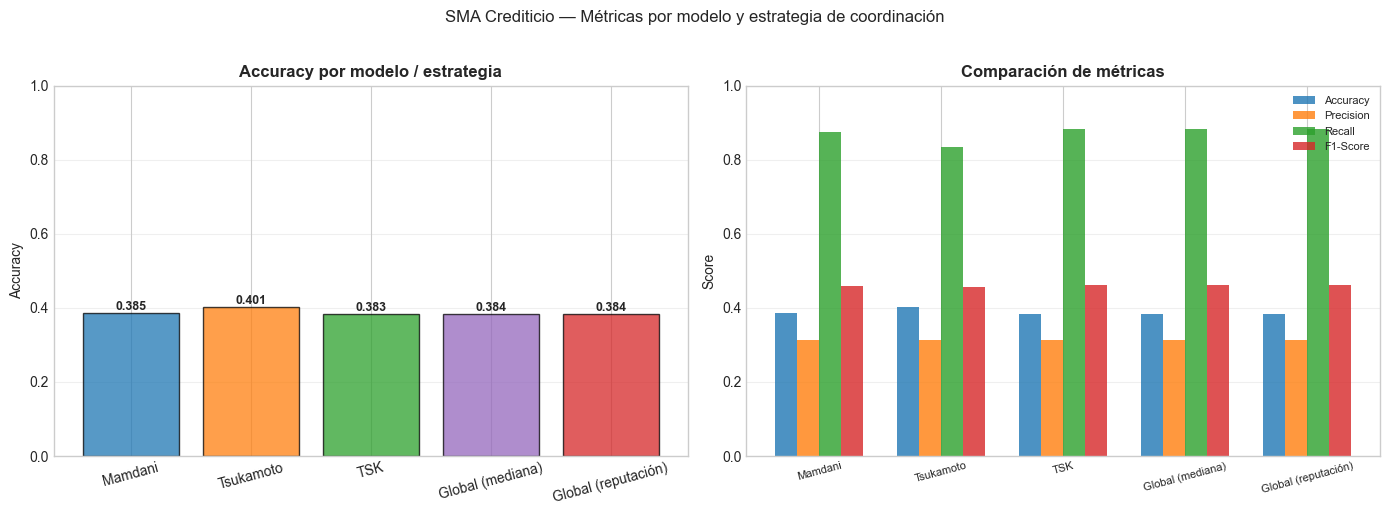

In [18]:
# [11.1] Barras de métricas comparativas
# ────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

modelos = df_comp['Modelo'].values
colores = ['#1f77b4','#ff7f0e','#2ca02c','#9467bd','#d62728']

# Panel 1 — Accuracy
ax = axes[0]
bars = ax.bar(modelos, df_comp['Accuracy'], color=colores, alpha=0.75, edgecolor='black')
for bar, val in zip(bars, df_comp['Accuracy']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_title('Accuracy por modelo / estrategia', fontweight='bold')
ax.set_ylabel('Accuracy')
ax.set_ylim(0, 1)
ax.tick_params(axis='x', rotation=15)
ax.grid(True, alpha=0.3, axis='y')

# Panel 2 — Todas las métricas agrupadas
ax = axes[1]
metricas_cols = ['Accuracy','Precision','Recall','F1-Score']
x_pos  = np.arange(len(modelos))
width  = 0.18
for i, met in enumerate(metricas_cols):
    ax.bar(x_pos + i*width, df_comp[met], width, label=met, alpha=0.8)
ax.set_xticks(x_pos + width*1.5)
ax.set_xticklabels(modelos, rotation=15, fontsize=8)
ax.set_title('Comparación de métricas', fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('SMA Crediticio — Métricas por modelo y estrategia de coordinación',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


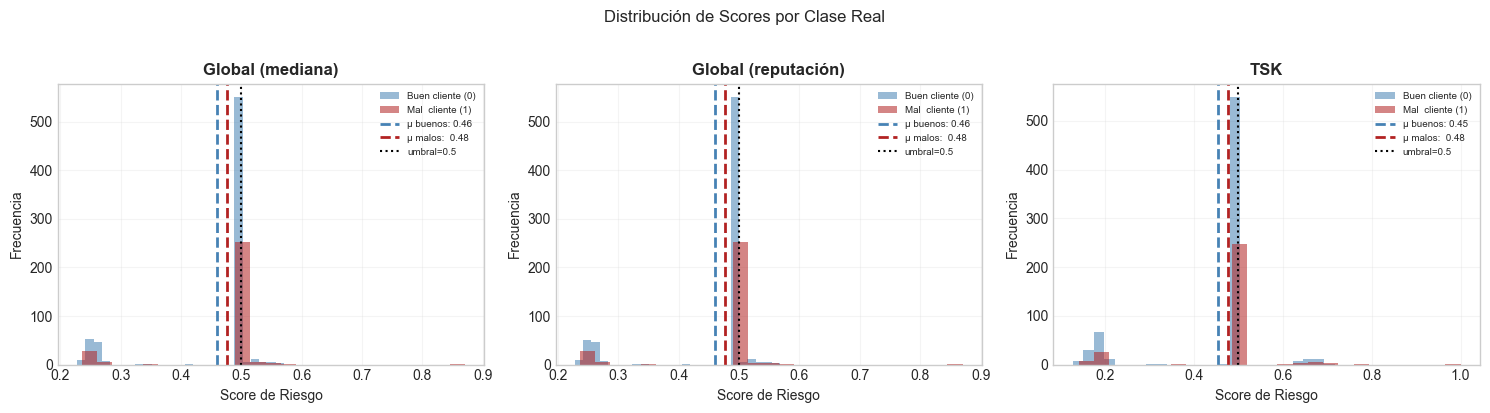

In [19]:
# [11.2] Distribución de scores por clase real
# ──────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

pares = [
    ("Global (mediana)",    scores_global),
    ("Global (reputación)", scores_rep),
    ("TSK",                 scores_per_agent['TSK']),
]

for ax, (titulo, scores) in zip(axes, pares):
    buenos = scores[y_true == 0]
    malos  = scores[y_true == 1]
    ax.hist(buenos, bins=25, alpha=0.55, color='steelblue', label='Buen cliente (0)')
    ax.hist(malos,  bins=25, alpha=0.55, color='firebrick',  label='Mal  cliente (1)')
    ax.axvline(buenos.mean(), color='steelblue', lw=2, linestyle='--',
               label=f'μ buenos: {buenos.mean():.2f}')
    ax.axvline(malos.mean(),  color='firebrick',  lw=2, linestyle='--',
               label=f'μ malos:  {malos.mean():.2f}')
    ax.axvline(0.5, color='black', lw=1.5, linestyle=':', label='umbral=0.5')
    ax.set_title(titulo, fontweight='bold')
    ax.set_xlabel('Score de Riesgo')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.2)

plt.suptitle('Distribución de Scores por Clase Real', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


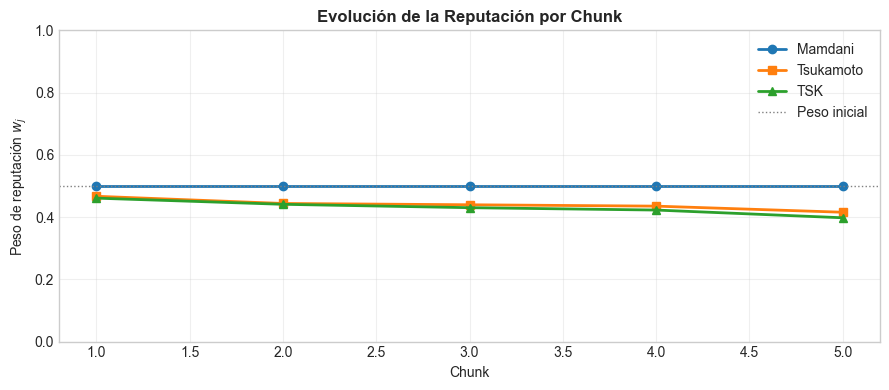

In [20]:
# [11.3] Evolución de la reputación
# ───────────────────────────────────

chunks_n = [h[0] for h in coord_rep.historia_rep]
rep_m    = [h[1].get('Mamdani',   0.5) for h in coord_rep.historia_rep]
rep_t    = [h[1].get('Tsukamoto', 0.5) for h in coord_rep.historia_rep]
rep_k    = [h[1].get('TSK',       0.5) for h in coord_rep.historia_rep]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(chunks_n, rep_m, 'o-', label='Mamdani',   lw=2)
ax.plot(chunks_n, rep_t, 's-', label='Tsukamoto', lw=2)
ax.plot(chunks_n, rep_k, '^-', label='TSK',       lw=2)
ax.axhline(0.5, color='gray', linestyle=':', lw=1, label='Peso inicial')
ax.set_title('Evolución de la Reputación por Chunk', fontweight='bold')
ax.set_xlabel('Chunk')
ax.set_ylabel('Peso de reputación $w_j$')
ax.set_ylim(0, 1)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


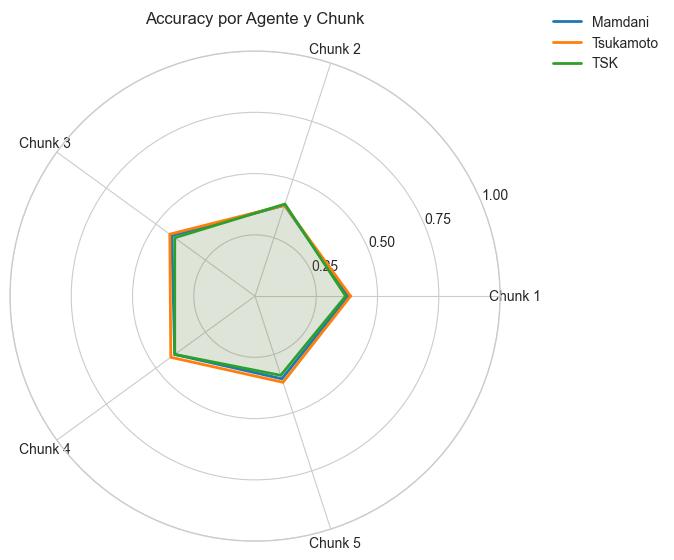

  t+ 7.17s │ chunk 4/5 │ Mamdani      │ media=0.457  [3 en pizarra]
  t+ 8.85s │ chunk 5/5 │ Mamdani      │ media=0.464  [3 en pizarra]


In [21]:
# [11.4] Gráfica radar: divergencia por chunk
# ─────────────────────────────────────────────

# Accuracy de cada agente por chunk
def acc_chunk(nombre, chunk_idx):
    snap   = bb.pizarra[chunk_idx]
    if nombre not in snap: return np.nan
    scores = snap[nombre]
    preds  = (np.array(scores) >= 0.5).astype(int)
    return accuracy_score(y_chunks[chunk_idx], preds)

N  = N_CHUNKS
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

def cerrar(data): return data + data[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
colores = ['tab:blue','tab:orange','tab:green']

for nombre, col in zip(['Mamdani','Tsukamoto','TSK'], colores):
    vals = [acc_chunk(nombre, c) for c in range(N_CHUNKS)]
    vals = [v if not np.isnan(v) else 0 for v in vals]
    ax.plot(angles, cerrar(vals), lw=2, label=nombre, color=col)
    ax.fill(angles, cerrar(vals), alpha=0.08, color=col)

ax.set_xticks(angles[:-1])
ax.set_xticklabels([f"Chunk {i+1}" for i in range(N_CHUNKS)])
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_title('Accuracy por Agente y Chunk', size=12, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))
plt.tight_layout()
plt.show()


<div style="border: 2px solid #24398A; border-radius: 15px; padding: 20px; background-color: #fcfcfc;">
    <h3 style="color: #24398A; margin-top: 0;">Conclusiones: Inteligencia Colectiva para Riesgo Crediticio</h3>
    <p style="font-size: 15px; line-height: 1.6;">
        Construimos un Sistema Multiagente que encapsula tres modelos de inferencia difusa en agentes
        autónomos concurrentes. El patrón Blackboard permitió que los agentes operaran en paralelo y
        que el coordinador integrara sus propuestas con quórum parcial, replicando la arquitectura
        de la libreta 06 en un dominio de clasificación por lotes.
    </p>
    <ul style="font-size: 14px; color: #333;">
        <li><b>Diversidad de perspectivas:</b> Mamdani, Tsukamoto y TSK producen scores distintos
            para el mismo solicitante porque sus estrategias de inferencia son fundamentalmente
            diferentes. Esa diversidad es el activo principal del SMA.</li>
        <li><b>Reputación como mecanismo de confianza:</b> El coordinador con reputación dinámica
            implementa una forma simplificada del principio MQDM: las opiniones se ponderan por
            historial de aciertos, no por autoridad nominal.</li>
        <li><b>Tolerancia a fallos:</b> Cuando un agente lento no alcanza el quórum, el sistema
            avanza con los disponibles. La pizarra registra la ausencia sin colapsar.</li>
        <li><b>Interpretabilidad preservada:</b> A diferencia de los métodos ensemble de caja negra,
            cada propuesta en la pizarra es auditable: sabemos qué regla difusa la generó.</li>
    </ul>
</div>